# Kalman Filter for Linear-Gaussian State Estimation

## Overview

The **Kalman filter** is the optimal recursive Bayesian estimator for a linear dynamical
system driven by Gaussian noise.
It was introduced by Rudolf Kálmán in 1960 and immediately transformed navigation,
control engineering, and signal processing.
Today it remains central to GPS receivers, autonomous vehicles, weather forecasting,
and financial time-series analysis.

### Why the Kalman Filter Matters

- It provides the **exact MMSE (minimum mean-squared error)** estimate of a hidden state,
  given noisy observations, under linearity and Gaussianity.
- The two-step **predict–update** structure makes it causal and highly efficient:
  only the mean and covariance of the state need to be maintained.
- It is a special case of the Bayesian filter, and the foundation for the
  **Extended Kalman Filter**, **Unscented Kalman Filter**, and **particle filters**.

### What This Notebook Demonstrates

1. A 2D state following a noisy spiral trajectory (rotation matrix dynamics).
2. Three scalar measurements per step with independent noise.
3. The full predict–update recursion, storing posterior means and covariance norms.
4. Visualization of: true state, noisy measurements, filtered estimate, and $3\sigma$ uncertainty ellipses.
5. Effect of varying the measurement noise covariance $R$.

### State-Space Model

**State evolution** (process model):

$$
x_{k+1} = F\, x_k + w_k, \qquad w_k \sim \mathcal{N}(0, Q),
$$

**Observation model**:

$$
z_k = H\, x_k + v_k, \qquad v_k \sim \mathcal{N}(0, R).
$$

Here $x_k \in \mathbb{R}^d$ is the hidden state and $z_k \in \mathbb{R}^m$ is the observation.
In this notebook $d = 2$, $m = 3$.

### Kalman Filter Recursion

**Predict step** (prior):

$$
\hat{x}_{k|k-1} = F\, \hat{x}_{k-1|k-1}, \qquad
P_{k|k-1} = F\, P_{k-1|k-1}\, F^T + Q.
$$

**Update step** (posterior):

$$
K_k = P_{k|k-1}\, H^T \bigl(H\, P_{k|k-1}\, H^T + R\bigr)^{-1},
$$

$$
\hat{x}_{k|k} = \hat{x}_{k|k-1} + K_k\bigl(z_k - H\,\hat{x}_{k|k-1}\bigr),
$$

$$
P_{k|k} = (I - K_k H)\, P_{k|k-1}.
$$

The matrix $K_k$ is the **Kalman gain**: it weighs how much to trust the prediction
vs. the new measurement based on their relative uncertainties.

### Setup and Model Parameters

We define the model matrices:

- $F$: a rotation matrix $\begin{pmatrix}\cos\theta & -\sin\theta \\ \sin\theta & \cos\theta\end{pmatrix}$ with $\theta = 0.3$ rad,
  slightly scaled by $s = 0.98$ to produce an inward spiral.
- $H \in \mathbb{R}^{3 \times 2}$: random measurement matrix (fixed seed).
- $Q = q^2 I_2$: isotropic process noise.
- $R = r^2 I_3$: isotropic measurement noise.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse

rng = np.random.default_rng(7)

# --- Model dimensions ---
d = 2   # state dimension
m = 3   # observation dimension
T = 80  # time steps

# --- State transition: spiral (rotation + contraction) ---
theta = 0.3        # rotation angle per step (rad)
s     = 0.98       # contraction factor
F = s * np.array([[np.cos(theta), -np.sin(theta)],
                   [np.sin(theta),  np.cos(theta)]])

# --- Measurement matrix (random, fixed) ---
H = rng.standard_normal((m, d))

# --- Noise covariances ---
q = 0.08   # process noise std
r = 0.5    # measurement noise std
Q = q**2 * np.eye(d)
R = r**2 * np.eye(m)

print(f'State dim d={d}, obs dim m={m}, T={T} steps')
print(f'Process noise std q={q}, measurement noise std r={r}')

State dim d=2, obs dim m=3, T=80 steps
Process noise std q=0.08, measurement noise std r=0.5


### Simulating the State and Observations

We generate the ground-truth trajectory $\{x_k\}$ and the noisy observations $\{z_k\}$:

$$
x_0 = \begin{pmatrix}3 \\ 0\end{pmatrix}, \qquad
x_{k+1} = F x_k + w_k, \qquad z_k = H x_k + v_k.
$$

The spiral nature of $F$ means the trajectory winds inward over time.

In [2]:
x0_true = np.array([3.0, 0.0])

X_true = np.zeros((T+1, d))
Z_obs  = np.zeros((T,   m))

X_true[0] = x0_true
for k in range(T):
    X_true[k+1] = F @ X_true[k] + rng.multivariate_normal(np.zeros(d), Q)
    Z_obs[k]    = H @ X_true[k] + rng.multivariate_normal(np.zeros(m), R)

print(f'True trajectory: {X_true.shape}, observations: {Z_obs.shape}')
print(f'True state range x1: [{X_true[:,0].min():.2f}, {X_true[:,0].max():.2f}]')

True trajectory: (81, 2), observations: (80, 3)
True state range x1: [-2.28, 3.00]


### Kalman Filter Implementation

The filter maintains the Gaussian posterior $p(x_k \mid z_{1:k}) = \mathcal{N}(\hat{x}_{k|k}, P_{k|k})$.
At each step we first **predict** (propagate prior through dynamics),
then **update** (condition on new observation).

The innovation (residual) $\nu_k = z_k - H\hat{x}_{k|k-1}$ quantifies surprise:
large $|\nu_k|$ means the observation disagrees with the prediction.

In [3]:
def kalman_filter(F, H, Q, R, x0_hat, P0, Z_obs):
    """Run Kalman filter. Returns posterior means and covariances."""
    T_steps = Z_obs.shape[0]
    d = F.shape[0]
    X_hat  = np.zeros((T_steps+1, d))   # posterior means
    P_trace = np.zeros(T_steps+1)        # trace of posterior cov
    P_all  = np.zeros((T_steps+1, d, d))

    X_hat[0]  = x0_hat
    P_current = P0.copy()
    P_all[0]  = P_current
    P_trace[0]= np.trace(P_current)

    for k in range(T_steps):
        # --- Predict ---
        x_pred = F @ X_hat[k]
        P_pred = F @ P_current @ F.T + Q

        # --- Update ---
        S = H @ P_pred @ H.T + R          # innovation covariance
        K = P_pred @ H.T @ np.linalg.inv(S)  # Kalman gain
        nu = Z_obs[k] - H @ x_pred           # innovation

        X_hat[k+1]  = x_pred + K @ nu
        P_current   = (np.eye(d) - K @ H) @ P_pred
        P_all[k+1]  = P_current
        P_trace[k+1]= np.trace(P_current)

    return X_hat, P_all, P_trace

# Initial estimate: zero mean, large uncertainty
x0_hat = np.zeros(d)
P0     = 10.0 * np.eye(d)

X_hat, P_all, P_trace = kalman_filter(F, H, Q, R, x0_hat, P0, Z_obs)

# Reconstruction error
err = np.linalg.norm(X_hat[1:] - X_true[1:], axis=1)
print(f'Mean estimation error: {err.mean():.4f}')
print(f'Final posterior trace: {P_trace[-1]:.4f}')

Mean estimation error: 0.4637
Final posterior trace: 0.0699


### Trajectory Visualization

We plot three things:
1. The **true state** trajectory (solid black).
2. The **Kalman estimate** (solid blue), which smoothly tracks the true state.
3. The **$3\sigma$ uncertainty ellipses** from the posterior covariance $P_{k|k}$
   (drawn at select time steps), showing how uncertainty evolves.

The ellipse at step $k$ represents the set
$\{x : (x - \hat{x}_k)^T P_k^{-1} (x - \hat{x}_k) \leq 9\}$.

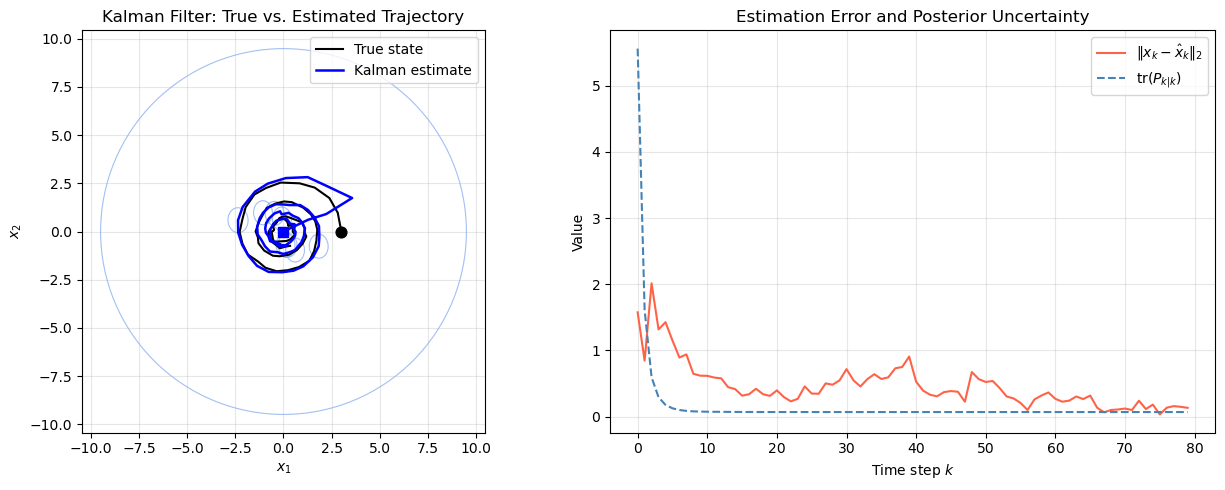

In [4]:
def plot_ellipse(ax, mean, cov, n_std=3.0, **kwargs):
    """Draw a covariance ellipse on ax."""
    vals, vecs = np.linalg.eigh(cov)
    vals = np.maximum(vals, 0)
    angle = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))
    width, height = 2 * n_std * np.sqrt(vals)
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ell)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left panel: 2D trajectory ---
ax = axes[0]
ax.plot(X_true[:, 0], X_true[:, 1], 'k-', lw=1.5, label='True state', zorder=3)
ax.plot(X_hat[:, 0],  X_hat[:, 1],  'b-', lw=1.8, label='Kalman estimate', zorder=4)
ax.scatter(*X_true[0], color='k', s=60, zorder=5)
ax.scatter(*X_hat[0],  color='b', s=60, marker='s', zorder=5)

# Uncertainty ellipses at select steps
for k in range(0, T+1, 10):
    plot_ellipse(ax, X_hat[k], P_all[k], n_std=3.0,
                 fill=False, edgecolor='cornflowerblue', lw=0.8, alpha=0.6)

ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Kalman Filter: True vs. Estimated Trajectory')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# --- Right panel: estimation error and posterior trace ---
ax2 = axes[1]
ax2.plot(err, color='tomato', lw=1.5, label='$\\|x_k - \\hat{x}_k\\|_2$')
ax2.plot(P_trace[1:], color='steelblue', lw=1.5, linestyle='--',
         label='$\\operatorname{tr}(P_{k|k})$')
ax2.set_xlabel('Time step $k$')
ax2.set_ylabel('Value')
ax2.set_title('Estimation Error and Posterior Uncertainty')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kalman_trajectory.png', dpi=90, bbox_inches='tight')
plt.show()

### Effect of Measurement Noise Level $r$

The Kalman gain $K_k$ automatically adjusts to the signal-to-noise ratio.
When $r$ (measurement noise std) is large, $K_k$ is small and the filter trusts
the prediction more than the measurement.
When $r \to 0$, the filter trusts measurements completely.

We compare mean estimation errors across a range of $r$ values,
using the same true trajectory.

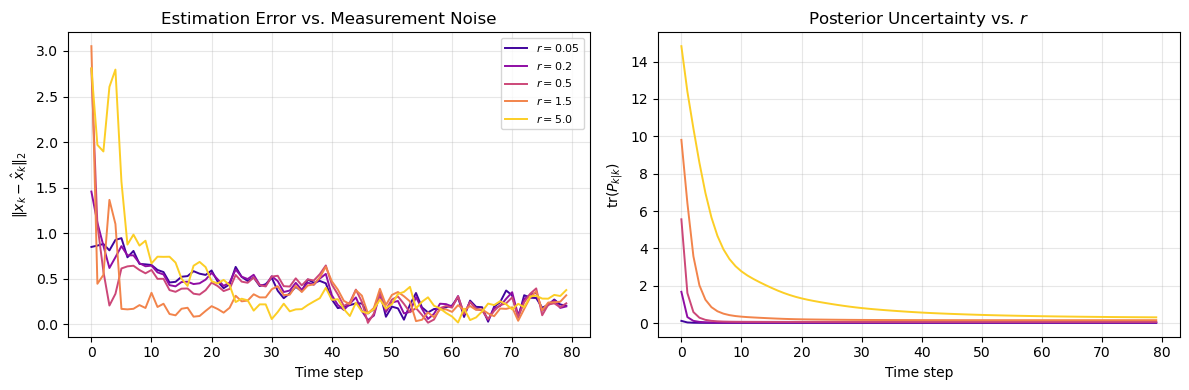

In [5]:
r_values = [0.05, 0.2, 0.5, 1.5, 5.0]
palette = plt.cm.plasma(np.linspace(0.1, 0.9, len(r_values)))

fig, axes2 = plt.subplots(1, 2, figsize=(12, 4))

for r_val, col in zip(r_values, palette):
    R_val = r_val**2 * np.eye(m)
    # Re-generate observations with this r
    rng2 = np.random.default_rng(42)
    Z_new = np.array([H @ X_true[k] + rng2.multivariate_normal(np.zeros(m), R_val)
                      for k in range(T)])
    Xh, _, Ptr = kalman_filter(F, H, Q, R_val, np.zeros(d), P0, Z_new)
    err_r = np.linalg.norm(Xh[1:] - X_true[1:], axis=1)
    axes2[0].plot(err_r, color=col, lw=1.4, label=f'$r={r_val}$')
    axes2[1].plot(Ptr[1:], color=col, lw=1.4)

axes2[0].set_xlabel('Time step'); axes2[0].set_ylabel('$\\|x_k - \\hat{x}_k\\|_2$')
axes2[0].set_title('Estimation Error vs. Measurement Noise')
axes2[0].legend(fontsize=8); axes2[0].grid(True, alpha=0.3)

axes2[1].set_xlabel('Time step'); axes2[1].set_ylabel('$\\operatorname{tr}(P_{k|k})$')
axes2[1].set_title('Posterior Uncertainty vs. $r$')
axes2[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kalman_noise_effect.png', dpi=90, bbox_inches='tight')
plt.show()

### Static Snapshot

Generates `snippet.png` for the repository gallery — a compact version of the
trajectory and estimation error plots.

In [6]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt
    import numpy as _np
    from matplotlib.patches import Ellipse as _Ell

    _rng = _np.random.default_rng(7)
    _d, _m, _T = 2, 3, 80
    _theta, _s = 0.3, 0.98
    _F = _s * _np.array([[_np.cos(_theta), -_np.sin(_theta)],
                          [_np.sin(_theta),  _np.cos(_theta)]])
    _H  = _rng.standard_normal((_m, _d))
    _Q  = (0.08**2) * _np.eye(_d)
    _R  = (0.5**2)  * _np.eye(_m)
    _Xt = _np.zeros((_T+1, _d)); _Zt = _np.zeros((_T, _m))
    _Xt[0] = [3., 0.]
    for _k in range(_T):
        _Xt[_k+1] = _F @ _Xt[_k] + _rng.multivariate_normal(_np.zeros(_d), _Q)
        _Zt[_k]   = _H @ _Xt[_k] + _rng.multivariate_normal(_np.zeros(_m), _R)

    def _kf(F, H, Q, R, x0, P0, Z):
        T_ = Z.shape[0]; d_ = F.shape[0]
        Xh = _np.zeros((T_+1, d_)); Pa = _np.zeros((T_+1, d_, d_))
        Xh[0] = x0; Pc = P0.copy(); Pa[0] = Pc
        for k_ in range(T_):
            xp = F @ Xh[k_]; Pp = F @ Pc @ F.T + Q
            S_ = H @ Pp @ H.T + R; Kg = Pp @ H.T @ _np.linalg.inv(S_)
            Xh[k_+1] = xp + Kg @ (Z[k_] - H @ xp)
            Pc = (_np.eye(d_) - Kg @ H) @ Pp; Pa[k_+1] = Pc
        return Xh, Pa

    _Xh, _Pa = _kf(_F, _H, _Q, _R, _np.zeros(_d), 10*_np.eye(_d), _Zt)
    _err = _np.linalg.norm(_Xh[1:] - _Xt[1:], axis=1)

    _fig, (_a1, _a2) = _plt.subplots(1, 2, figsize=(8, 4))
    _a1.plot(_Xt[:,0], _Xt[:,1], 'k-', lw=1.4, label='True')
    _a1.plot(_Xh[:,0], _Xh[:,1], 'b-', lw=1.6, label='KF estimate')
    for _k in range(0, _T+1, 15):
        _v, _ve = _np.linalg.eigh(_Pa[_k])
        _v = _np.maximum(_v, 0)
        _ang = _np.degrees(_np.arctan2(_ve[1,1], _ve[0,1]))
        _e = _Ell(xy=_Xh[_k], width=2*3*_np.sqrt(_v[0]),
                  height=2*3*_np.sqrt(_v[1]), angle=_ang,
                  fill=False, edgecolor='cornflowerblue', lw=0.7, alpha=0.6)
        _a1.add_patch(_e)
    _a1.set_aspect('equal'); _a1.set_title('Trajectory', fontsize=10)
    _a1.legend(fontsize=8); _a1.grid(True, alpha=.3)

    _a2.plot(_err, color='tomato', lw=1.5)
    _a2.set_title('Estimation Error', fontsize=10)
    _a2.set_xlabel('Time step'); _a2.set_ylabel('Error')
    _a2.grid(True, alpha=.3)

    _fig.suptitle('Kalman Filter', fontsize=12)
    _plt.tight_layout()
    _plt.savefig('snippet.png', dpi=100, bbox_inches='tight')
    _plt.close(_fig)
    print('snippet.png saved.')

snippet.png saved.


### Interactive: Vary Process and Measurement Noise

Use the sliders to change $q$ (process noise) and $r$ (measurement noise).
Observe how the Kalman gain and trajectory tracking change:

- Large $r$: filter trusts the dynamics model more, smoother estimate.
- Large $q$: filter trusts measurements more, noisier but responsive estimate.

## Takeaways

- The Kalman filter is the **exact Bayesian filter** for linear-Gaussian models:
  the posterior is always Gaussian and maintained in closed form.
- The **predict** step propagates uncertainty forward using the dynamics;
  the **update** step reduces uncertainty using the new measurement.
- The **Kalman gain** $K_k$ automatically balances prediction and measurement trust
  based on their covariances: no manual tuning required once $Q$ and $R$ are known.
- The steady-state gain (reached after the transient from $P_0$) depends only
  on $(F, H, Q, R)$ and can be pre-computed by solving the discrete algebraic Riccati equation.
- Large $r$ (noisy sensors) → small $K$ → smoother but slower-tracking estimates.
- Large $q$ (unpredictable dynamics) → large $K$ → noisier but faster-adapting estimates.

## Bibliography

- R. E. Kálmán, *A New Approach to Linear Filtering and Prediction Problems*,
  Transactions of the ASME — Journal of Basic Engineering, 1960.
- B. D. O. Anderson and J. B. Moore, *Optimal Filtering*, Prentice-Hall, 1979.
- S. Sarkka, *Bayesian Filtering and Smoothing*, Cambridge University Press, 2013.
- R. Durbin, J. Eddy, A. Krogh, G. Mitchison, *Biological Sequence Analysis*,
  Cambridge University Press, 1998. (Chapter on HMMs and Kalman filters.)